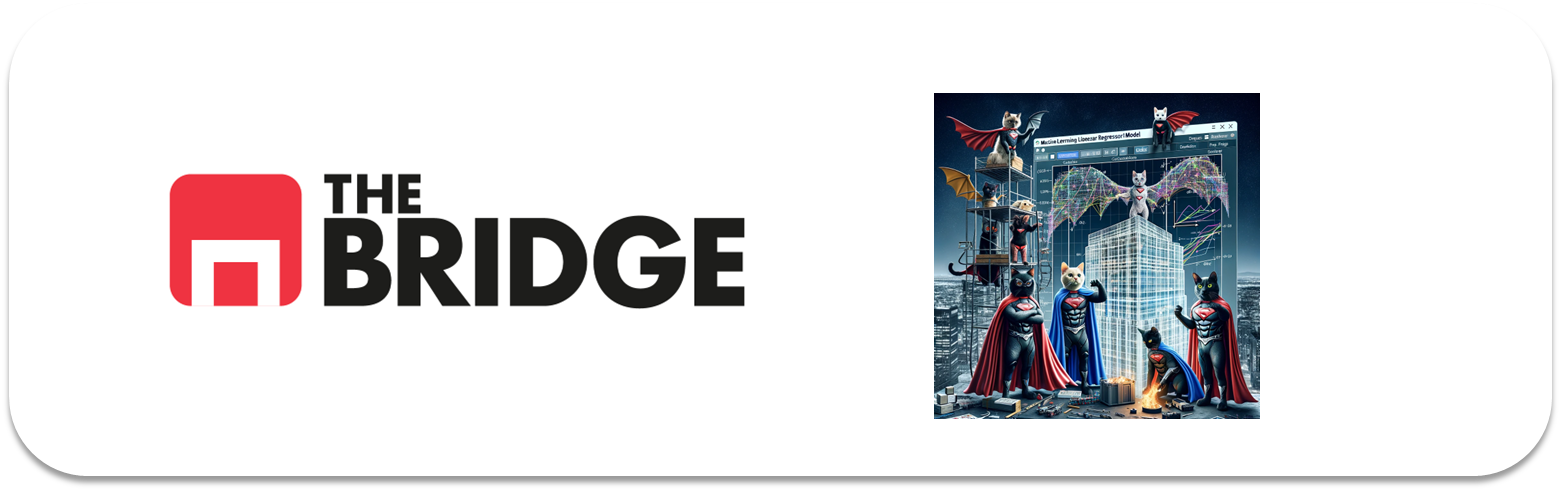

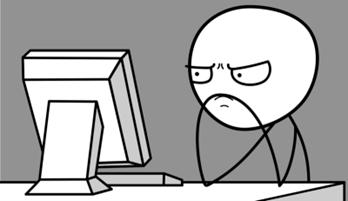

Para ejercitarte y afianzar lo aprendido sobre **Regresión Logística para clasificación binaria**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Inicio: Entendiendo el problema

En este caso el objetivo de los ejercicios es hacer un modelado de regresión logística sobre el dataset conocidos como "Adults" o "Census Income" que permita casificar a las personas en si ganan más de 50K dolares o no, en función de una serie de características demográficas y de empleo. Sigue las instrucciones cuando sea necesario para poder continuar

El nombre de las columnas y sus valores se muestra a continuación (las columnas siguen el mismo orden que en el fichero, por si tuvieras que utilizar estos nombres)

age: edad, continuous.  

workclass: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked.  

fnlwgt: continuous (a eliminar)  

education: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool.  

education-num: continuous.  

marital-status: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse.  

occupation: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces.

relationship: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried.  

race: White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black.  

sex: Female, Male.  

capital-gain: continuous.  

capital-loss: continuous.  

hours-per-week: continuous.  

native-country: United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands.  


### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

### Ejercicio 1: Carga de datos y vistazo


Carga el conjunto de datos de TRAIN ("./data/adult.data") en un dataframe (tendrás que explorar el tipo de archivo y darle nombre a las columnas). Muestra la descripción de los datos y las primeras filas del conjunto de datos.

*Cargamos los datos, que es un poco tricky*

In [2]:
column_names = ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 
                'marital_status', 'occupation', 'relationship', 'race', 'sex', 
                'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']

df = pd.read_csv("./data/adult.data", header=None, names=column_names, skipinitialspace=True)
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


### Ejercicio 2: Preparación y limpieza de Datos (I)

En una situación normal tendríamos que revisar el dataset para ver qué podemos limpiar (convertir tipos, cambiar valores raros, etc) y sólo no deberíamos imputar faltantes sobre el dataset global. Aquí te dirigiré los pasos:

1. Quita los espacios iniciales y finales de todos los valores string del dataset.
2. Comprueba que 'workclass', 'occupation', 'native_country' contienen un valor "raro", que indica los faltantes (este es un ejemplo de dataset con "missing" que no están marcados por np.NaN)
3. Deshazte de las columna "fnlwgt" que ni se entiende, ni se necesita y deshazte de las filas con esos faltantes (tenemos muchos datos y poco "tiempo").

1. Quita los espacios iniciales y finales de todos los valores string del dataset.

In [4]:
print(repr(df["workclass"].iloc[0]))

'State-gov'


In [5]:
for col in df.select_dtypes(include=object):
    df[col] = df[col].str.strip()

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


2. Comprueba que 'workclass', 'occupation', 'native_country' contienen un valor "raro", que indica los faltantes 

In [6]:
print("workclass unique values:", df["workclass"].unique())
print("-" * 100)
print("Ocupation unique values:", df["occupation"].unique())
print("-" * 100)
print("Native_country unique values:", df["native_country"].unique())

workclass unique values: ['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' '?'
 'Self-emp-inc' 'Without-pay' 'Never-worked']
----------------------------------------------------------------------------------------------------
Ocupation unique values: ['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' '?'
 'Protective-serv' 'Armed-Forces' 'Priv-house-serv']
----------------------------------------------------------------------------------------------------
Native_country unique values: ['United-States' 'Cuba' 'Jamaica' 'India' '?' 'Mexico' 'South'
 'Puerto-Rico' 'Honduras' 'England' 'Canada' 'Germany' 'Iran'
 'Philippines' 'Italy' 'Poland' 'Columbia' 'Cambodia' 'Thailand' 'Ecuador'
 'Laos' 'Taiwan' 'Haiti' 'Portugal' 'Dominican-Republic' 'El-Salvador'
 'France' 'Guatemala' 'China' 'Japan' 'Yugoslavia' 'Peru'
 'Outlying-US(Guam-USVI-etc)' 

In [7]:
for col in df.columns:
    if df[col].dtype == "object":
        if "?" in df[col].values:
            df[col] = df[col].replace("?", np.nan)
        

In [8]:
df.isna().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

In [9]:
df = df.dropna()
df.isna().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30162 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             30162 non-null  int64 
 1   workclass       30162 non-null  object
 2   fnlwgt          30162 non-null  int64 
 3   education       30162 non-null  object
 4   education_num   30162 non-null  int64 
 5   marital_status  30162 non-null  object
 6   occupation      30162 non-null  object
 7   relationship    30162 non-null  object
 8   race            30162 non-null  object
 9   sex             30162 non-null  object
 10  capital_gain    30162 non-null  int64 
 11  capital_loss    30162 non-null  int64 
 12  hours_per_week  30162 non-null  int64 
 13  native_country  30162 non-null  object
 14  income          30162 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


3. Deshazte de las columna "fnlwgt" que ni se entiende, ni se necesita y deshazte de las filas con esos faltantes (tenemos muchos datos y poco "tiempo").

In [11]:
df = df.drop("fnlwgt", axis=1)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30162 entries, 0 to 32560
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             30162 non-null  int64 
 1   workclass       30162 non-null  object
 2   education       30162 non-null  object
 3   education_num   30162 non-null  int64 
 4   marital_status  30162 non-null  object
 5   occupation      30162 non-null  object
 6   relationship    30162 non-null  object
 7   race            30162 non-null  object
 8   sex             30162 non-null  object
 9   capital_gain    30162 non-null  int64 
 10  capital_loss    30162 non-null  int64 
 11  hours_per_week  30162 non-null  int64 
 12  native_country  30162 non-null  object
 13  income          30162 non-null  object
dtypes: int64(5), object(9)
memory usage: 3.5+ MB


In [13]:
df[df.duplicated()]

,age,workclass,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
352,33,Private,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,>50K
391,27,Private,Bachelors,13,Never-married,Craft-repair,Not-in-family,White,Male,0,0,50,United-States,<=50K
563,24,Private,HS-grad,9,Never-married,Handlers-cleaners,Unmarried,Black,Female,0,0,40,United-States,<=50K
570,24,Private,HS-grad,9,Never-married,Craft-repair,Own-child,White,Male,0,0,40,United-States,<=50K
673,33,Private,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,>50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32503,47,Private,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K
32512,20,Private,HS-grad,9,Never-married,Machine-op-inspct,Own-child,White,Male,0,0,40,United-States,<=50K
32527,22,Private,Some-college,10,Never-married,Adm-clerical,Own-child,White,Male,0,0,40,United-States,<=50K
32557,40,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K


In [14]:
total_filas = len(df)
duplicados = df.duplicated().sum()
porcentaje = (duplicados / total_filas) * 100
print(f"Total filas: {total_filas}, Duplicados: {duplicados}")
print(f"Porcentaje de duplicados: {porcentaje:.2f}%")

Total filas: 30162, Duplicados: 3258
Porcentaje de duplicados: 10.80%


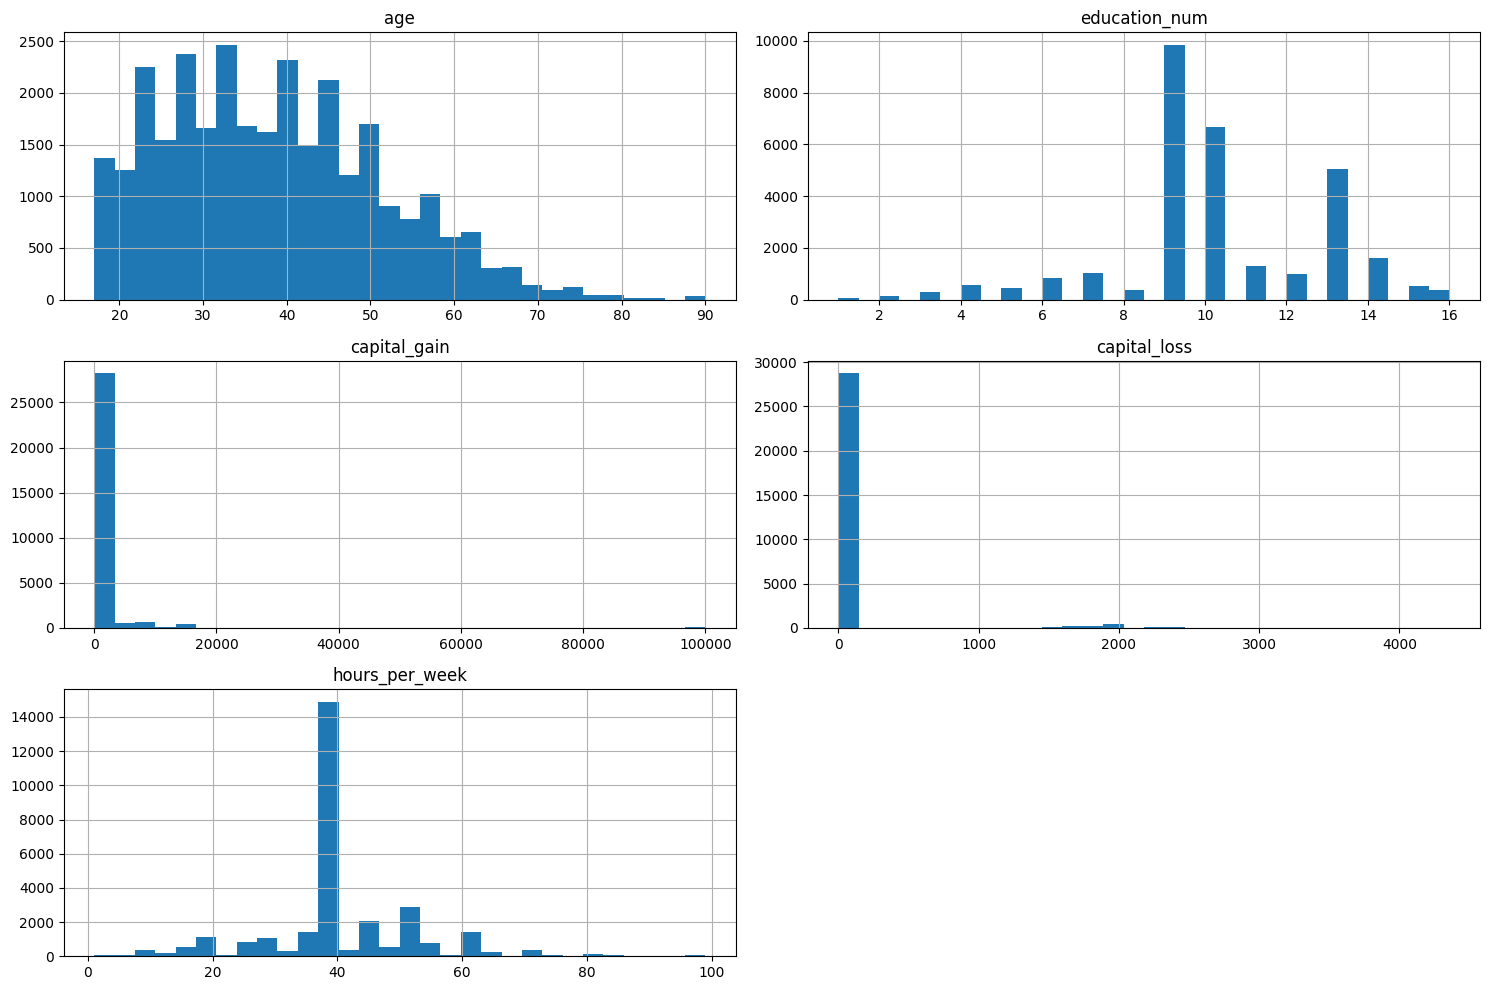

In [15]:
df.hist(bins=30, figsize=(15,10))
plt.tight_layout()
plt.show();

### Ejercicio 3: Preparación y limpieza de Datos (II)

Muestra el reparto de valores de "native-country". Convierte la variable en una binara con 1 para ciudadanos norteamericanos y 0 para el resto.

NOTA: En otras ocasiones lo hubieramos tratados por continentes por ejemplo, pero de primeras la diferencia de distribución es tan alta que es mejor simplificar que no quedarse con todos los valores

In [16]:
df["native_country"].head(20)

0     United-States
1     United-States
2     United-States
3     United-States
4              Cuba
5     United-States
6           Jamaica
7     United-States
8     United-States
9     United-States
10    United-States
11            India
12    United-States
13    United-States
15           Mexico
16    United-States
17    United-States
18    United-States
19    United-States
20    United-States
Name: native_country, dtype: object

In [17]:
df.loc[df["native_country"] == "United-States", "native_country"] = 1
df.loc[df["native_country"] != 1, "native_country"] = 0

In [18]:
df["native_country"].head(20)

0     1
1     1
2     1
3     1
4     0
5     1
6     0
7     1
8     1
9     1
10    1
11    0
12    1
13    1
15    0
16    1
17    1
18    1
19    1
20    1
Name: native_country, dtype: object

### Ejercicio 4: Preparación y limpieza de Datos (III)

Escoge la variable target, ¿qué particularidad tiene?¿qué debemos hacer con ella? Hazlo.

In [19]:
target = df["income"].copy()
target

0        <=50K
1        <=50K
2        <=50K
3        <=50K
4        <=50K
         ...  
32556    <=50K
32557     >50K
32558    <=50K
32559    <=50K
32560     >50K
Name: income, Length: 30162, dtype: object

In [20]:
# Tambien debemos transformar la variable target en binaria para poder hacer regresion logistica y asi predecir si una persona gana mas de 50k o no.

In [21]:
target.unique()

array(['<=50K', '>50K'], dtype=object)

In [22]:
target.loc[target == "<=50K"] = 0
target.loc[target == ">50K"] = 1

In [23]:
df.select_dtypes(include=object).columns

Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'native_country', 'income'],
      dtype='object')

In [24]:
df2 = df.copy()

In [25]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30162 entries, 0 to 32560
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             30162 non-null  int64 
 1   workclass       30162 non-null  object
 2   education       30162 non-null  object
 3   education_num   30162 non-null  int64 
 4   marital_status  30162 non-null  object
 5   occupation      30162 non-null  object
 6   relationship    30162 non-null  object
 7   race            30162 non-null  object
 8   sex             30162 non-null  object
 9   capital_gain    30162 non-null  int64 
 10  capital_loss    30162 non-null  int64 
 11  hours_per_week  30162 non-null  int64 
 12  native_country  30162 non-null  object
 13  income          30162 non-null  object
dtypes: int64(5), object(9)
memory usage: 3.5+ MB


### Ejercicio 5: Preparar variables categóricas (I)

Prepara las variables categóricas, salvo "education" y "native_country" (o su equivalente si no la has llamado así al connvertirla en binaria), convirtiéndolas con un one-hot encoding (usa el pd.get_dummies). NOTA: Recuerda que este es el dataset de train, por eso lo atacamos directamente.

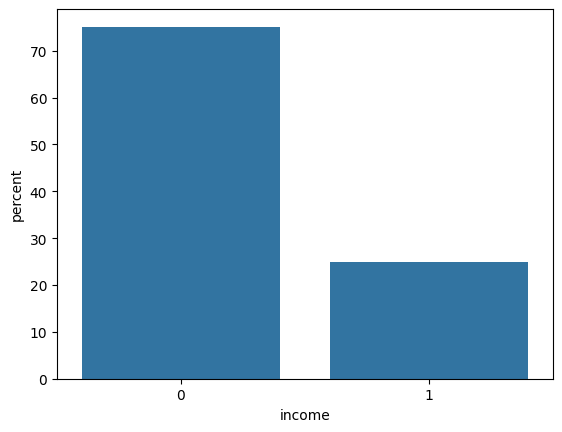

In [26]:
sns.countplot(data=df2, x=target, stat="percent");

In [27]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30162 entries, 0 to 32560
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             30162 non-null  int64 
 1   workclass       30162 non-null  object
 2   education       30162 non-null  object
 3   education_num   30162 non-null  int64 
 4   marital_status  30162 non-null  object
 5   occupation      30162 non-null  object
 6   relationship    30162 non-null  object
 7   race            30162 non-null  object
 8   sex             30162 non-null  object
 9   capital_gain    30162 non-null  int64 
 10  capital_loss    30162 non-null  int64 
 11  hours_per_week  30162 non-null  int64 
 12  native_country  30162 non-null  object
 13  income          30162 non-null  object
dtypes: int64(5), object(9)
memory usage: 3.5+ MB


### Ejercicio 6: Preparar variables categóricas (II)

Codifica la variable "education" usando un ordinal encoding, no uses la codificación por defecto, elígela tú y razónala o bien demuestra pillería y que has revisado el dataset.

In [28]:
education_niveles = {
'Preschool':0,
'1st-4th':1,
'5th-6th':2, 
'7th-8th':3, 
'9th':4,
'10th':5, 
'11th':6, 
'12th':7,
'HS-grad':8,
'Some-college':9,
'Assoc-voc':10, 
'Assoc-acdm':11, 
'Bachelors':12,
'Prof-school':13,
'Masters':14, 
'Doctorate':15  
 }

df2["education"] = df2["education"].map(education_niveles)

df2 = pd.get_dummies(df2, columns=['workclass', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'income'])

# Drop education_num since we manually encoded education
df2 = df2.drop('education_num', axis=1)

df2.head()


,age,education,capital_gain,capital_loss,hours_per_week,native_country,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,...,relationship_Wife,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Female,sex_Male,income_<=50K,income_>50K
0,39,12,2174,0,40,1,False,False,False,False,...,False,False,False,False,False,True,False,True,True,False
1,50,12,0,0,13,1,False,False,False,False,...,False,False,False,False,False,True,False,True,True,False
2,38,8,0,0,40,1,False,False,True,False,...,False,False,False,False,False,True,False,True,True,False
3,53,6,0,0,40,1,False,False,True,False,...,False,False,False,True,False,False,False,True,True,False
4,28,12,0,0,40,0,False,False,True,False,...,True,False,False,True,False,False,True,False,True,False


In [29]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30162 entries, 0 to 32560
Data columns (total 49 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   age                                   30162 non-null  int64 
 1   education                             30162 non-null  int64 
 2   capital_gain                          30162 non-null  int64 
 3   capital_loss                          30162 non-null  int64 
 4   hours_per_week                        30162 non-null  int64 
 5   native_country                        30162 non-null  object
 6   workclass_Federal-gov                 30162 non-null  bool  
 7   workclass_Local-gov                   30162 non-null  bool  
 8   workclass_Private                     30162 non-null  bool  
 9   workclass_Self-emp-inc                30162 non-null  bool  
 10  workclass_Self-emp-not-inc            30162 non-null  bool  
 11  workclass_State-gov              

NOTA: En un ejercicio completo deberíamos decidir si escalar las variables numéricas contínuas, si quieres puedes hacero tú como extra y comparar con el modelo que vamos a completar en este conjunto de ejercicios.

In [30]:
from sklearn.model_selection import train_test_split 

# income se convierte en income_<=50K e income_>50K después de get_dummies
# usamos income_>50K como target (1 = >50K)
y = df2["income_>50K"]
X = df2.drop(["income_<=50K", "income_>50K"], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Double check: asegúrate de que NO hay income columns en X_train ni X_test
if "income_>50K" in X_train.columns:
    X_train = X_train.drop("income_>50K", axis=1)
    X_test = X_test.drop("income_>50K", axis=1)
if "income_<=50K" in X_train.columns:
    X_train = X_train.drop("income_<=50K", axis=1)
    X_test = X_test.drop("income_<=50K", axis=1)

print("✓ income columns eliminadas. X_train shape:", X_train.shape)

✓ income columns eliminadas. X_train shape: (24129, 47)


In [31]:
from sklearn.preprocessing import StandardScaler

# Guardar nombres de columnas ANTES de escalar
feature_names = X_train.columns

# Escalar las features después del split (para evitar data leakage)
# Fit SOLO en train, luego transform en ambos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reconvertir a DataFrame para preservar nombres de columnas
X_train = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test = pd.DataFrame(X_test_scaled, columns=feature_names)

print("✓ Features escaladas. X_train shape:", X_train.shape)
print("✓ X_test shape:", X_test.shape)

✓ Features escaladas. X_train shape: (24129, 47)
✓ X_test shape: (6033, 47)


In [32]:
# CHEQUEO: Verificar correlaciones sospechosas con target
correlations = pd.concat([X_train, y_train], axis=1).corr()['income_>50K'].sort_values(ascending=False)
print("Top 10 features por correlación con target:")
print(correlations.head(15))
print("\n" + "="*60)
print("Features con correlación > 0.7 (posible leakage):")
high_corr = correlations[correlations.abs() > 0.7]
print(high_corr)
print("\nColumns en X_train:")
print(X_train.columns.tolist())

Top 10 features por correlación con target:
income_>50K                         1.000000
sex_Female                          0.016284
occupation_Priv-house-serv          0.014743
workclass_Private                   0.013428
marital_status_Separated            0.011930
relationship_Other-relative         0.011141
race_Amer-Indian-Eskimo             0.010595
marital_status_Married-AF-spouse    0.008651
relationship_Unmarried              0.008362
occupation_Sales                    0.007995
workclass_Without-pay               0.006749
marital_status_Divorced             0.006563
marital_status_Widowed              0.005946
occupation_Adm-clerical             0.004546
occupation_Craft-repair             0.003984
Name: income_>50K, dtype: float64

Features con correlación > 0.7 (posible leakage):
income_>50K    1.0
Name: income_>50K, dtype: float64

Columns en X_train:
['age', 'education', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'workclass_Federal-gov', 'workcla

In [33]:
# ELIMINAR DATA LEAKAGE: sacar income_>50K y income_<=50K de features
for col in ['income_>50K', 'income_<=50K']:
    if col in X_train.columns:
        X_train = X_train.drop(col, axis=1)
        X_test = X_test.drop(col, axis=1)
        print(f"✓ Eliminada columna con leakage: {col}")

print(f"\nNueva forma X_train: {X_train.shape}")
print(f"Nueva forma X_test: {X_test.shape}")


Nueva forma X_train: (24129, 47)
Nueva forma X_test: (6033, 47)


### Ejercicio 7: Modelo (I)

Instancia el modelo de regresión logística, con el hiperparámetro "max_iter" a 10000.

In [34]:
from sklearn.linear_model import LogisticRegression

# Check class distribution
print("Class distribution in training data:")
print(y_train.value_counts(normalize=True))

# Use class_weight='balanced' to handle class imbalance
lr = LogisticRegression(max_iter=10000, class_weight='balanced')


Class distribution in training data:
income_>50K
False    0.752248
True     0.247752
Name: proportion, dtype: float64


### Ejercicio 8: Entrenamiento

Entrena modelo para el dataset de train tal como lo hemos preparado, creando antes el dataset sólo de features (X_train) y la serie con los valores del target (y_train). NOTA: Deshazte de "education_num" si has codificado tú a mano "education".

In [35]:
lr.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


### Ejercicio 9: Evaluación (I)

Previo a la evaluación necesitamos obtener y preparar el dataset de test. Carga el dataset a partir de "./data/adult.test". Luego aplícale las mismas operaciones que has realizado sobre el train. (NOTA; Puede que tengas que cambiar alguna cosa en la variable "income" para convertirla)

In [36]:
df_test = pd.read_csv("./data/adult.test", header=None, names = column_names, skipinitialspace = True)
df_test.head(5)

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K.
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K.
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K.
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K.
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K.


In [37]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16281 entries, 0 to 16280
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             16281 non-null  int64 
 1   workclass       16281 non-null  object
 2   fnlwgt          16281 non-null  int64 
 3   education       16281 non-null  object
 4   education_num   16281 non-null  int64 
 5   marital_status  16281 non-null  object
 6   occupation      16281 non-null  object
 7   relationship    16281 non-null  object
 8   race            16281 non-null  object
 9   sex             16281 non-null  object
 10  capital_gain    16281 non-null  int64 
 11  capital_loss    16281 non-null  int64 
 12  hours_per_week  16281 non-null  int64 
 13  native_country  16281 non-null  object
 14  income          16281 non-null  object
dtypes: int64(6), object(9)
memory usage: 1.9+ MB


In [38]:
for col in df_test.select_dtypes(include=object):
    df_test[col] = df_test[col].str.strip()

# Remove trailing periods (common in test files)
for col in df_test.select_dtypes(include=object):
    df_test[col] = df_test[col].str.rstrip('.')

df_test.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [39]:
for col in df_test.columns:
    if df_test[col].dtype == "object":
        if "?" in df_test[col].values:
            df_test[col] = df_test[col].replace("?", np.nan)

# Remove trailing periods and convert native_country
for col in df_test.select_dtypes(include=object):
    df_test[col] = df_test[col].str.rstrip('.')

df_test.loc[df_test["native_country"] == "United-States", "native_country"] = 1
df_test.loc[df_test["native_country"] != 1, "native_country"] = 0

In [40]:
df_test.isna().sum()

age                 0
workclass         963
fnlwgt              0
education           0
education_num       0
marital_status      0
occupation        966
relationship        0
race                0
sex                 0
capital_gain        0
capital_loss        0
hours_per_week      0
native_country      0
income              0
dtype: int64

In [41]:
df_test = df_test.dropna()
df_test = df_test.drop("fnlwgt", axis=1)
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15315 entries, 0 to 16280
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             15315 non-null  int64 
 1   workclass       15315 non-null  object
 2   education       15315 non-null  object
 3   education_num   15315 non-null  int64 
 4   marital_status  15315 non-null  object
 5   occupation      15315 non-null  object
 6   relationship    15315 non-null  object
 7   race            15315 non-null  object
 8   sex             15315 non-null  object
 9   capital_gain    15315 non-null  int64 
 10  capital_loss    15315 non-null  int64 
 11  hours_per_week  15315 non-null  int64 
 12  native_country  15315 non-null  object
 13  income          15315 non-null  object
dtypes: int64(5), object(9)
memory usage: 1.8+ MB


In [42]:
df_test.isna().sum()

age               0
workclass         0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [43]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15315 entries, 0 to 16280
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             15315 non-null  int64 
 1   workclass       15315 non-null  object
 2   education       15315 non-null  object
 3   education_num   15315 non-null  int64 
 4   marital_status  15315 non-null  object
 5   occupation      15315 non-null  object
 6   relationship    15315 non-null  object
 7   race            15315 non-null  object
 8   sex             15315 non-null  object
 9   capital_gain    15315 non-null  int64 
 10  capital_loss    15315 non-null  int64 
 11  hours_per_week  15315 non-null  int64 
 12  native_country  15315 non-null  object
 13  income          15315 non-null  object
dtypes: int64(5), object(9)
memory usage: 1.8+ MB


### Ejercicio 10: Evaluación (II)

Obten la predicción para X_train y para X_test.

In [44]:
df_test["education"] = df_test["education"].map(education_niveles)

df_test = pd.get_dummies(df_test, columns=['workclass', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'income'])

df_test = df_test.drop('education_num', axis=1)

df_test.head()

,age,education,capital_gain,capital_loss,hours_per_week,native_country,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,...,relationship_Wife,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Female,sex_Male,income_<=50K,income_>50K
0,25,6,0,0,40,1,False,False,True,False,...,False,False,False,True,False,False,False,True,True,False
1,38,8,0,0,50,1,False,False,True,False,...,False,False,False,False,False,True,False,True,True,False
2,28,11,0,0,40,1,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True
3,44,9,7688,0,40,1,False,False,True,False,...,False,False,False,True,False,False,False,True,False,True
5,34,5,0,0,30,1,False,False,True,False,...,False,False,False,False,False,True,False,True,True,False


In [45]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15315 entries, 0 to 16280
Data columns (total 49 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   age                                   15315 non-null  int64 
 1   education                             15315 non-null  int64 
 2   capital_gain                          15315 non-null  int64 
 3   capital_loss                          15315 non-null  int64 
 4   hours_per_week                        15315 non-null  int64 
 5   native_country                        15315 non-null  object
 6   workclass_Federal-gov                 15315 non-null  bool  
 7   workclass_Local-gov                   15315 non-null  bool  
 8   workclass_Private                     15315 non-null  bool  
 9   workclass_Self-emp-inc                15315 non-null  bool  
 10  workclass_Self-emp-not-inc            15315 non-null  bool  
 11  workclass_State-gov              

In [46]:
print(df_test.columns.tolist())
df2["education"]

['age', 'education', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'workclass_Federal-gov', 'workclass_Local-gov', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Without-pay', 'marital_status_Divorced', 'marital_status_Married-AF-spouse', 'marital_status_Married-civ-spouse', 'marital_status_Married-spouse-absent', 'marital_status_Never-married', 'marital_status_Separated', 'marital_status_Widowed', 'occupation_Adm-clerical', 'occupation_Armed-Forces', 'occupation_Craft-repair', 'occupation_Exec-managerial', 'occupation_Farming-fishing', 'occupation_Handlers-cleaners', 'occupation_Machine-op-inspct', 'occupation_Other-service', 'occupation_Priv-house-serv', 'occupation_Prof-specialty', 'occupation_Protective-serv', 'occupation_Sales', 'occupation_Tech-support', 'occupation_Transport-moving', 'relationship_Husband', 'relationship_Not-in-family', 'relationship_Other-relative', 'relationship_Own-child', '

0        12
1        12
2         8
3         6
4        12
         ..
32556    11
32557     8
32558     8
32559     8
32560     8
Name: education, Length: 30162, dtype: int64

In [47]:

# Now predict
y_pred_train = lr.predict(X_train)
y_pred_test = lr.predict(X_test)

### Ejercicio 11: Evaluación (III)

Muestra la matriz de confusión para los resultados de train, así como el clasification_report de sklearn

<Axes: >

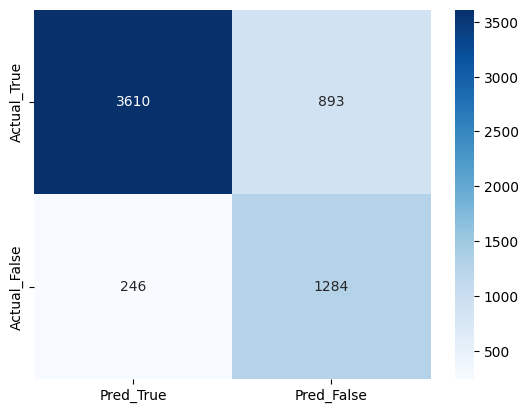

In [48]:
from sklearn.metrics import confusion_matrix

c_matrix = confusion_matrix(y_test, y_pred_test)

c_matrix_df = pd.DataFrame(c_matrix, columns= ["Pred_True","Pred_False"],
                           index = ["Actual_True", "Actual_False"])

sns.heatmap(c_matrix_df, annot=True, fmt='d', cmap='Blues')

### Ejercicio 12: Evaluación (IV)
Muestra la matriz de confusión y el classification report para los resultados del test. Comparála con los de train.

TRAIN Confusion Matrix:


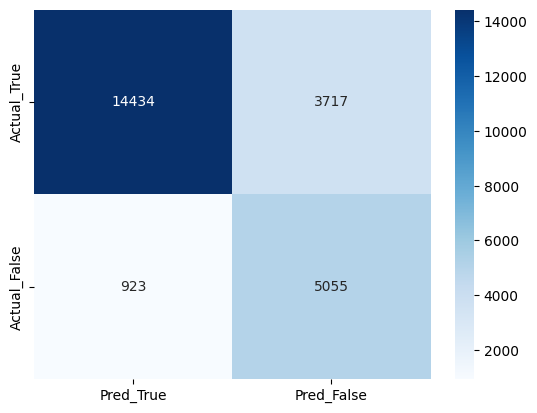


TRAIN Classification Report:
              precision    recall  f1-score   support

       False       0.94      0.80      0.86     18151
        True       0.58      0.85      0.69      5978

    accuracy                           0.81     24129
   macro avg       0.76      0.82      0.77     24129
weighted avg       0.85      0.81      0.82     24129



TEST Confusion Matrix:


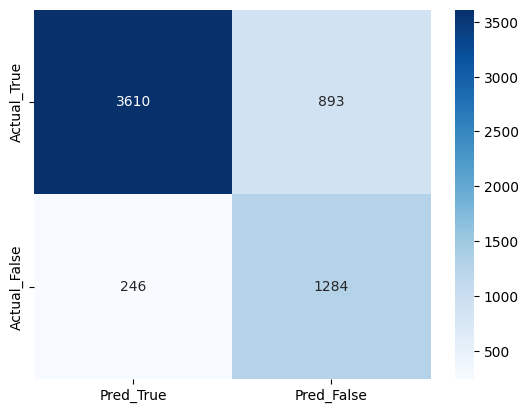


TEST Classification Report:
              precision    recall  f1-score   support

       False       0.94      0.80      0.86      4503
        True       0.59      0.84      0.69      1530

    accuracy                           0.81      6033
   macro avg       0.76      0.82      0.78      6033
weighted avg       0.85      0.81      0.82      6033



In [49]:
from sklearn.metrics import confusion_matrix, classification_report

# Train confusion matrix
c_matrix_train = confusion_matrix(y_train, y_pred_train)
c_matrix_train_df = pd.DataFrame(c_matrix_train, columns=["Pred_True", "Pred_False"],
                                  index=["Actual_True", "Actual_False"])
print("TRAIN Confusion Matrix:")
sns.heatmap(c_matrix_train_df, annot=True, fmt='d',cmap="Blues")
plt.show()

print("\nTRAIN Classification Report:")
print(classification_report(y_train, y_pred_train))

# Test confusion matrix
print("\n\nTEST Confusion Matrix:")
sns.heatmap(c_matrix_df, annot=True, fmt='d',cmap="Blues")
plt.show()

print("\nTEST Classification Report:")
print(classification_report(y_test, y_pred_test))


### Extra: 

1. Muestra la curva ROC de test.

2. Muestra los coeficientes y su importancia.

AUROC: 0.91


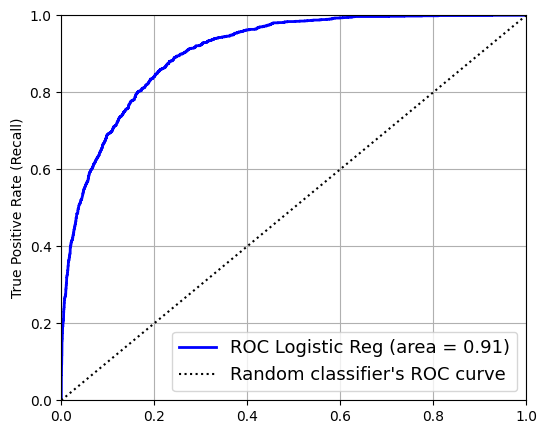

In [50]:
from sklearn.metrics import roc_curve, auc
scores = lr.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, scores[:,1])
roc_auc = auc(fpr,tpr)
print("AUROC: %.2f" %(roc_auc))
plt.figure(figsize=(6, 5))  
plt.plot(fpr, tpr, linewidth=2, color= "blue", label=f"ROC Logistic Reg (area = {roc_auc:0.2f})")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.ylabel('True Positive Rate (Recall)')
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=13);

In [51]:
np.sort(lr.coef_)

array([[-0.57199349, -0.36437712, -0.26506337, -0.23849934, -0.23227722,
        -0.21939287, -0.19520801, -0.15123061, -0.14822943, -0.14442251,
        -0.13389445, -0.10490827, -0.10243947, -0.09782572, -0.09354008,
        -0.08653794, -0.05997674, -0.04982322, -0.03768225, -0.03642538,
        -0.03200333, -0.03018042, -0.02993622, -0.02315395,  0.00699287,
         0.02991691,  0.03687096,  0.03866097,  0.05188643,  0.05856005,
         0.06599743,  0.07875133,  0.0880736 ,  0.09272684,  0.09644476,
         0.10698458,  0.19520801,  0.1957259 ,  0.19990226,  0.23859162,
         0.24436386,  0.24727397,  0.41269381,  0.41568887,  0.68917752,
         0.82466194,  2.34506489]])

Train AuROC: 0.9047
Test AuROC: 0.9072


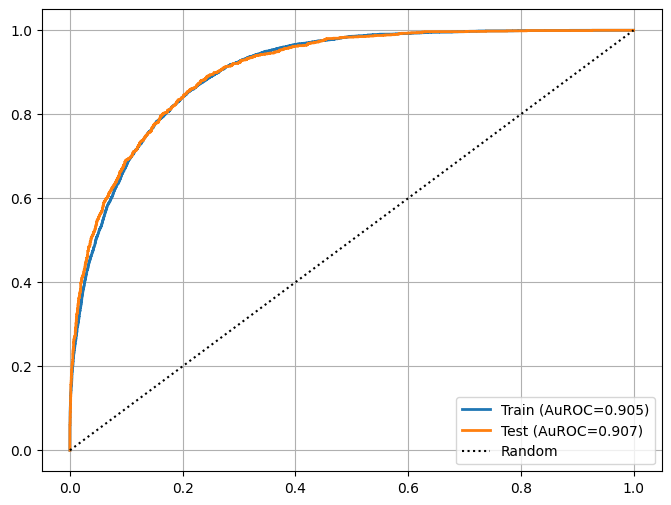

In [ ]:
# Train ROC
scores_train = lr.predict_proba(X_train)
fpr_train, tpr_train, _ = roc_curve(y_train, scores_train[:,1])
roc_auc_train = auc(fpr_train, tpr_train)

# Test ROC
scores_test = lr.predict_proba(X_test)
fpr_test, tpr_test, _ = roc_curve(y_test, scores_test[:,1])
roc_auc_test = auc(fpr_test, tpr_test)

print(f"Train AuROC: {roc_auc_train:.4f}")
print(f"Test AuROC: {roc_auc_test:.4f}")

# Las dos juntas
plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f"Train (AuROC={roc_auc_train:.3f})", linewidth=2)
plt.plot(fpr_test, tpr_test, label=f"Test (AuROC={roc_auc_test:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], 'k:', label="Random")
plt.legend()
plt.grid()
plt.show()